In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import time
import time
from scipy.sparse import load_npz

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TRAINING MODELS FOR DETECTING FAKE NEWS")
print("="*60)


TRAINING MODELS FOR DETECTING FAKE NEWS


In [4]:
X_train = load_npz('data/processed/X_train_tfidf.npz')
X_test = load_npz('data/processed/X_test_tfidf.npz')
y_train = np.load('data/processed/y_train.npy')
y_test = np.load('data/processed/y_test.npy')

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")
print(f"Распределение в train: REAL={sum(y_train==1)}, FAKE={sum(y_train==0)}")
print(f"Распределение в test: REAL={sum(y_test==1)}, FAKE={sum(y_test==0)}")

# Download vectorizer
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)
print("✓ Векторизатор загружен из models/tfidf_vectorizer.pkl")


Размер train: (35918, 5000)
Размер test: (8980, 5000)
Распределение в train: REAL=17133, FAKE=18785
Распределение в test: REAL=4284, FAKE=4696
✓ Векторизатор загружен из models/tfidf_vectorizer.pkl


In [6]:
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test):
    """
    Train model and outputs quality metrics.
    """
    print(f"TRAIN: {model_name}")
    
    # Measuring learning time
    start_time = time.time()
    
    # Train model
    model.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Output results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 score: {f1:.4f}")
    
    if roc_auc:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Learning time: {training_time}")
    
    # Detailed report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['FAKE', 'REAL'],
                yticklabels=['FAKE', 'REAL'])
    plt.title(f'Confusion matrix - {model_name}')
    plt.ylabel('Reality')
    plt.xlabel('Prediction')
    plt.show()
    
    return {
        'model': model,
        'name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc-auc': roc_auc,
        'training_time': training_time,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
# Dictionary for storing results
results = {}


LOGISTIC REGRESSION
Class weight: {0: np.float64(0.956028746340165), 1: np.float64(1.04821105468978)}
TRAIN: Logistic regression
Accuracy: 0.9918
Precision: 0.9879
Recall: 0.9949
F1 score: 0.9914
ROC-AUC: 0.9995
Learning time: 0.8417587280273438

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



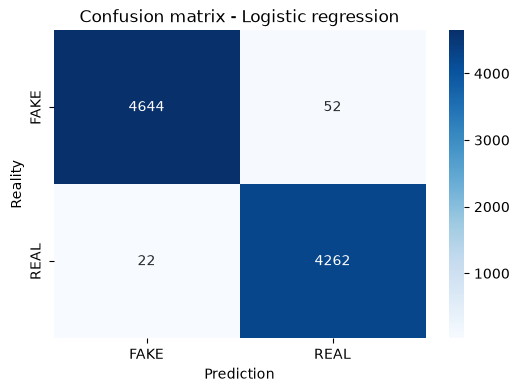

Logistic regression saved in 'models/'


In [7]:
# Logistic regression
print("LOGISTIC REGRESSION")

# Calculating class weights for balancing
class_weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weight[0], 1: class_weight[1]}
print(f"Class weight: {class_weight_dict}")

# Create the model
log_reg = LogisticRegression(
    C=1.0,
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42,
    solver='liblinear'
)

results['log_reg'] = train_and_evaluate(
    log_reg, "Logistic regression",
    X_train, X_test, y_train, y_test
)

# Save model
with open('models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
print("Logistic regression saved in 'models/'")
